In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import f_oneway
import seaborn as sns
import numpy as np
import scipy.signal as signal
import neurokit2 as nk 

# Define the folder paths and sensors
base_folder_path = r'C:\Users\rusha\Desktop\Uni_Freiburg_Notes\MDD\pilot'
folders = ['abstract_images', 'panas', 'stroop_test', 'storytelling', 'videos', 'standard_images']
sensors = ['accelerometer', 'bvp', 'eda', 'systolicPeaks', 'temperature']

# Initialize a dictionary to store data for each subject, each sensor, and each condition
subject_dataframes = {subject: {folder: {sensor: pd.DataFrame() for sensor in sensors} 
                                for folder in folders} 
                      for subject in ['1', '2', '3']}

# Loop through each folder and extract data
for folder in folders:
    folder_path = os.path.join(base_folder_path, folder)
    for subject_folder in os.listdir(folder_path):
        subject_path = os.path.join(folder_path, subject_folder)
        if os.path.isdir(subject_path) and subject_folder in subject_dataframes:
            for sensor in sensors:
                file_path = os.path.join(subject_path, f'{sensor}.csv')
                if os.path.isfile(file_path):
                    df = pd.read_csv(file_path)
                    df['subject'] = subject_folder
                    df['sensor'] = sensor
                    df['condition'] = folder  # Adding condition to differentiate data
                    subject_dataframes[subject_folder][folder][sensor] = df
subject_metric_dfs = {}

# Iterate over subjects
for subject in subject_dataframes:
    subject_metric_dfs[subject] = {}
    
    # Iterate over experiments for each subject
    for experiment in subject_dataframes[subject]:
        subject_metric_dfs[subject][experiment] = {}
        
        # Iterate over metrics for each experiment
        for metric in subject_dataframes[subject][experiment]:
            df_name = f"df_{metric}_{subject}_{experiment}"
            subject_metric_dfs[subject][experiment][metric] = subject_dataframes[subject][experiment][metric]
            
            # Assign DataFrame to dynamically created variable name
            globals()[df_name] = subject_dataframes[subject][experiment][metric]

# NORMALIZATION

In [2]:
# List of all experiments you want to process
experiments = ['abstract_images', 'panas', 'standard_images', 'videos', 'stroop_test', 'storytelling']

# Iterate over each subject in subject_dataframes
for subject_id, data in subject_dataframes.items():
    # Iterate over each experiment for the current subject
    for experiment in experiments:
        # Check if the experiment data exists for the current subject
        if experiment in data:
            # Normalize TEMP
            if 'temp' in data[experiment]:
                temp_values = data[experiment]['temp']['values']
                data[experiment]['temp']['values'] = (temp_values - np.min(temp_values)) / (np.max(temp_values) - np.min(temp_values))
            
            # Normalize BVP
            if 'bvp' in data[experiment]:
                bvp_values = data[experiment]['bvp']['values']
                data[experiment]['bvp']['values'] = (bvp_values - np.min(bvp_values)) / (np.max(bvp_values) - np.min(bvp_values))

# Print confirmation or sample of updated data (optional)
# for subject_id, data in subject_dataframes.items():
#     print(f"Subject {subject_id} updated.")
#     for experiment in experiments:
#         if experiment in data:
#             print(f"Experiment: {experiment}")
#             if 'temp' in data[experiment]:
#                 print(f"TEMP values: {data[experiment]['temp']['values'][:5]}")
#             if 'bvp' in data[experiment]:
#                 print(f"BVP values: {data[experiment]['bvp']['values'][:5]}")


# Heart Rate Variability

In [3]:
import neurokit2 as nk
import numpy as np
import pandas as pd

# Functions to detect peaks and compute RR intervals
def detect_peaks(bvp_signal, sampling_rate=64):
    peak_data = nk.ppg_findpeaks(bvp_signal, sampling_rate=sampling_rate, method="elgendi")
    return peak_data['PPG_Peaks']

def compute_rr_intervals(peaks, sampling_rate=64):
    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / sampling_rate  # Convert to seconds
        return rr_intervals
    else:
        return []

def calculate_rr_variance(rr_intervals):
    if len(rr_intervals) > 1:
        # Calculate variance of RR intervals
        variance_rr_intervals = np.var(rr_intervals)
        return variance_rr_intervals
    else:
        return np.nan

# Function to process all experiments for a given subject
def process_subject(subject_data):
    hrv_results = {}
    for experiment_name, df_bvp in subject_data.items():
        bvp_signal = df_bvp['values']
        peaks = detect_peaks(bvp_signal)
        rr_intervals = compute_rr_intervals(peaks)
        '''NORMALIZATION'''
        rr_intervals = (rr_intervals - np.min(rr_intervals)) / (np.max(rr_intervals) - np.min(rr_intervals))
        ''''''
        hrv_variance = calculate_rr_variance(rr_intervals)
        hrv_results[experiment_name] = hrv_variance
    return hrv_results

# Example structure of subject_dataframes for each experiment
subject_dataframes_hrv = {
    '1': {
        'abstract_images': df_bvp_1_abstract_images,
        'panas': df_bvp_1_panas,
        'stroop_test': df_bvp_1_stroop_test,
        'storytelling': df_bvp_1_storytelling,
        'videos': df_bvp_1_videos,
        'standard_images': df_bvp_1_standard_images,
    },
    '2': {
        'abstract_images': df_bvp_2_abstract_images,
        'panas': df_bvp_2_panas,
        'stroop_test': df_bvp_2_stroop_test,
        'storytelling': df_bvp_2_storytelling,
        'videos': df_bvp_2_videos,
        'standard_images': df_bvp_2_standard_images,
    },
    '3': {
        'abstract_images': df_bvp_3_abstract_images,
        'panas': df_bvp_3_panas,
        'stroop_test': df_bvp_3_stroop_test,
        'storytelling': df_bvp_3_storytelling,
        'videos': df_bvp_3_videos,
        'standard_images': df_bvp_3_standard_images,
    }
}

# Process each subject and store HRV results
hrv_subject_1 = process_subject(subject_dataframes_hrv['1'])
hrv_subject_2 = process_subject(subject_dataframes_hrv['2'])
hrv_subject_3 = process_subject(subject_dataframes_hrv['3'])

# Combine results into a DataFrame
hrv_combined = pd.DataFrame({
    'Subject 1': hrv_subject_1,
    'Subject 2': hrv_subject_2,
    'Subject 3': hrv_subject_3
})

print(hrv_combined)

                 Subject 1  Subject 2  Subject 3
abstract_images   0.016978   0.019510   0.011739
panas             0.009988   0.014648   0.031058
stroop_test       0.016713   0.015557   0.015541
storytelling      0.009819   0.027130   0.018944
videos            0.051922   0.051056   0.050003
standard_images   0.007991   0.012705   0.007217


# Variances

In [ ]:
# Calculate average intrapersonal variance for each experiment (task)
avg_intrapersonal_variance = df.var(axis=0).mean()  # Average of subject variances

# Calculate the intrapersonal variance for each task (average of variances across subjects)
intrapersonal_variance_per_task = df.var(axis=1)

# Calculate the interpersonal variance (variance between subjects for each task)
interpersonal_variance_per_task = df.var(axis=1)

# Create a combined dataframe for plotting
combined_variance = pd.DataFrame({
    'Intrapersonal Variance': intrapersonal_variance_per_task,
    'Interpersonal Variance': interpersonal_variance_per_task
})

# Plotting side by side
plt.figure(figsize=(12, 6))
combined_variance.plot(kind='bar', color=['skyblue', 'salmon'], width=0.7)
plt.title('Intra- and Interpersonal Variances Grouped by Experiment')
plt.xlabel('Experiments')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['Average Intrapersonal Variance', 'Interpersonal Variance'])

plt.tight_layout()
plt.show()


In [196]:
# Define a function to calculate intrapersonal variances
def calculate_intrapersonal_variances(df_bvp, df_eda, df_temperature, df_hrv):
    return {
        'BVP': df_bvp['values'].var(),
        'EDA': df_eda['values'].var(),
        'Temperature': df_temperature['values'].var(),
        'HRV': df_hrv
    }

# For each experiment, calculate intrapersonal variances
experiments = ['abstract_images', 'panas', 'stroop_test', 'storytelling', 'videos', 'standard_images']
subjects = ['1', '2', '3']

# Initialize a dictionary to hold the results
intrapersonal_variances_dict = {}

for experiment in experiments:
    intrapersonal_variances = {}
    
    for subject in subjects:
        # Extract the DataFrames for the current subject and experiment
        df_bvp = subject_dataframes[subject][experiment]['bvp']
        df_eda = subject_dataframes[subject][experiment]['eda']
        df_temperature = subject_dataframes[subject][experiment]['temperature']
        df_hrv = hrv_combined[f'Subject {subject}'][experiment]
        # Calculate intrapersonal variances
        variances = calculate_intrapersonal_variances(df_bvp, df_eda, df_temperature, df_hrv)
        
        # Add to the dictionary
        intrapersonal_variances[subject] = variances
    
    # Combine into a DataFrame
    intrapersonal_variances_df = pd.DataFrame(intrapersonal_variances).T
    intrapersonal_variances_dict[experiment] = intrapersonal_variances_df

# Now intrapersonal_variances_dict holds the DataFrames for each experiment
# You can access them as follows:
# intrapersonal_variances_dict['abstract_images']
# intrapersonal_variances_dict['panas']
# and so on...

# To visualize or work with these DataFrames, you can use:
for experiment, df in intrapersonal_variances_dict.items():
    print(f"Intrapersonal Variances for {experiment}:")
    print(df)
    print()

Intrapersonal Variances for abstract_images:
        BVP       EDA  Temperature       HRV
1  0.006413  0.000003     0.000114  0.016978
2  0.017853  0.000005     0.001689  0.019510
3  0.005401  0.001000     0.007707  0.011739

Intrapersonal Variances for panas:
        BVP       EDA  Temperature       HRV
1  0.002929  0.000003     0.003724  0.009988
2  0.007498  0.000149     0.018373  0.014648
3  0.006011  0.011347     0.011705  0.031058

Intrapersonal Variances for stroop_test:
        BVP       EDA  Temperature       HRV
1  0.003758  0.000002     0.001281  0.016713
2  0.022325  0.000113     0.007585  0.015557
3  0.005893  2.023173     0.001702  0.015541

Intrapersonal Variances for storytelling:
        BVP       EDA  Temperature       HRV
1  0.002272  0.000002     0.001819  0.009819
2  0.030699  0.000015     0.003384  0.027130
3  0.005173  0.000198     0.003973  0.018944

Intrapersonal Variances for videos:
        BVP       EDA  Temperature       HRV
1  0.019263  0.000006     0.0262

In [197]:
print(intrapersonal_variances_dict['panas'])

        BVP       EDA  Temperature       HRV
1  0.002929  0.000003     0.003724  0.009988
2  0.007498  0.000149     0.018373  0.014648
3  0.006011  0.011347     0.011705  0.031058


In [198]:
# # Define your variance calculations for each experiment as shown previously
# # Replace these with actual values calculated similarly as for 'abstract_images'

# # Example data for each subject and experiment:
# # In practice, you should replace these with actual calculations from your data.

# # For 'abstract_images'
# intra_variance_bvp_1_abstract_images = df_bvp_1_abstract_images['values'].var()
# intra_variance_eda_1_abstract_images = df_eda_1_abstract_images['values'].var()
# intra_variance_temp_1_abstract_images = df_temperature_1_abstract_images['values'].var()

# intra_variance_bvp_2_abstract_images = df_bvp_2_abstract_images['values'].var()
# intra_variance_eda_2_abstract_images = df_eda_2_abstract_images['values'].var()
# intra_variance_temp_2_abstract_images = df_temperature_2_abstract_images['values'].var()

# intra_variance_bvp_3_abstract_images = df_bvp_3_abstract_images['values'].var()
# intra_variance_eda_3_abstract_images = df_eda_3_abstract_images['values'].var()
# intra_variance_temp_3_abstract_images = df_temperature_3_abstract_images['values'].var()

hrv_1_abstract_images = hrv_combined["Subject 1"]["abstract_images"]  # Replace with actual HRV calculations
hrv_2_abstract_images = hrv_combined["Subject 2"]["abstract_images"]
hrv_3_abstract_images = hrv_combined["Subject 3"]["abstract_images"]

# # For each experiment, replace the placeholders with similar calculations
# # Example for 'panas'
# intra_variance_bvp_1_panas = df_bvp_1_panas['values'].var()
# intra_variance_eda_1_panas = df_eda_1_panas['values'].var()
# intra_variance_temp_1_panas = df_temperature_1_panas['values'].var()

# intra_variance_bvp_2_panas = df_bvp_2_panas['values'].var()
# intra_variance_eda_2_panas = df_eda_2_panas['values'].var()
# intra_variance_temp_2_panas = df_temperature_2_panas['values'].var()

# intra_variance_bvp_3_panas = df_bvp_3_panas['values'].var()
# intra_variance_eda_3_panas = df_eda_3_panas['values'].var()
# intra_variance_temp_3_panas = df_temperature_3_panas['values'].var()

hrv_1_panas = hrv_combined["Subject 1"]["panas"] 
hrv_2_panas = hrv_combined["Subject 2"]["panas"] 
hrv_3_panas = hrv_combined["Subject 3"]["panas"] 

# # For 'stroop_test'
# intra_variance_bvp_1_stroop_test = df_bvp_1_stroop_test['values'].var()
# intra_variance_eda_1_stroop_test = df_eda_1_stroop_test['values'].var()
# intra_variance_temp_1_stroop_test = df_temperature_1_stroop_test['values'].var()

# intra_variance_bvp_2_stroop_test = df_bvp_2_stroop_test['values'].var()
# intra_variance_eda_2_stroop_test = df_eda_2_stroop_test['values'].var()
# intra_variance_temp_2_stroop_test = df_temperature_2_stroop_test['values'].var()

# intra_variance_bvp_3_stroop_test = df_bvp_3_stroop_test['values'].var()
# intra_variance_eda_3_stroop_test = df_eda_3_stroop_test['values'].var()
# intra_variance_temp_3_stroop_test = df_temperature_3_stroop_test['values'].var()

hrv_1_stroop_test = hrv_combined["Subject 1"]["stroop_test"] 
hrv_2_stroop_test = hrv_combined["Subject 2"]["stroop_test"] 
hrv_3_stroop_test = hrv_combined["Subject 3"]["stroop_test"] 

# # For 'storytelling'
# intra_variance_bvp_1_storytelling = df_bvp_1_storytelling['values'].var()
# intra_variance_eda_1_storytelling = df_eda_1_storytelling['values'].var()
# intra_variance_temp_1_storytelling = df_temperature_1_storytelling['values'].var()

# intra_variance_bvp_2_storytelling = df_bvp_2_storytelling['values'].var()
# intra_variance_eda_2_storytelling = df_eda_2_storytelling['values'].var()
# intra_variance_temp_2_storytelling = df_temperature_2_storytelling['values'].var()

# intra_variance_bvp_3_storytelling = df_bvp_3_storytelling['values'].var()
# intra_variance_eda_3_storytelling = df_eda_3_storytelling['values'].var()
# intra_variance_temp_3_storytelling = df_temperature_3_storytelling['values'].var()

hrv_1_storytelling = hrv_combined["Subject 1"]["storytelling"] 
hrv_2_storytelling = hrv_combined["Subject 2"]["storytelling"] 
hrv_3_storytelling = hrv_combined["Subject 3"]["storytelling"] 

# # For 'videos'
# intra_variance_bvp_1_videos = df_bvp_1_videos['values'].var()
# intra_variance_eda_1_videos = df_eda_1_videos['values'].var()
# intra_variance_temp_1_videos = df_temperature_1_videos['values'].var()

# intra_variance_bvp_2_videos = df_bvp_2_videos['values'].var()
# intra_variance_eda_2_videos = df_eda_2_videos['values'].var()
# intra_variance_temp_2_videos = df_temperature_2_videos['values'].var()

# intra_variance_bvp_3_videos = df_bvp_3_videos['values'].var()
# intra_variance_eda_3_videos = df_eda_3_videos['values'].var()
# intra_variance_temp_3_videos = df_temperature_3_videos['values'].var()

hrv_1_videos = hrv_combined["Subject 1"]["videos"] 
hrv_2_videos = hrv_combined["Subject 2"]["videos"] 
hrv_3_videos = hrv_combined["Subject 3"]["videos"] 

# # For 'standard_images'
# intra_variance_bvp_1_standard_images = df_bvp_1_standard_images['values'].var()
# intra_variance_eda_1_standard_images = df_eda_1_standard_images['values'].var()
# intra_variance_temp_1_standard_images = df_temperature_1_standard_images['values'].var()

# intra_variance_bvp_2_standard_images = df_bvp_2_standard_images['values'].var()
# intra_variance_eda_2_standard_images = df_eda_2_standard_images['values'].var()
# intra_variance_temp_2_standard_images = df_temperature_2_standard_images['values'].var()

# intra_variance_bvp_3_standard_images = df_bvp_3_standard_images['values'].var()
# intra_variance_eda_3_standard_images = df_eda_3_standard_images['values'].var()
# intra_variance_temp_3_standard_images = df_temperature_3_standard_images['values'].var()

hrv_1_standard_images = hrv_combined["Subject 1"]["standard_images"] 
hrv_2_standard_images = hrv_combined["Subject 2"]["standard_images"] 
hrv_3_standard_images = hrv_combined["Subject 3"]["standard_images"] 

# # Combine intrapersonal variances into a DataFrame for each experiment
# intrapersonal_variances_dict = {
#     'abstract_images': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_abstract_images, 'Subject 2': hrv_2_abstract_images, 'Subject 3': hrv_3_abstract_images},
#         'BVP': {'Subject 1': intra_variance_bvp_1_abstract_images, 'Subject 2': intra_variance_bvp_2_abstract_images, 'Subject 3': intra_variance_bvp_3_abstract_images},
#         'EDA': {'Subject 1': intra_variance_eda_1_abstract_images, 'Subject 2': intra_variance_eda_2_abstract_images, 'Subject 3': intra_variance_eda_3_abstract_images},
#         'Temperature': {'Subject 1': intra_variance_temp_1_abstract_images, 'Subject 2': intra_variance_temp_2_abstract_images, 'Subject 3': intra_variance_temp_3_abstract_images}
#     }),
#     'panas': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_panas, 'Subject 2': hrv_2_panas, 'Subject 3': hrv_3_panas},
#         'BVP': {'Subject 1': intra_variance_bvp_1_panas, 'Subject 2': intra_variance_bvp_2_panas, 'Subject 3': intra_variance_bvp_3_panas},
#         'EDA': {'Subject 1': intra_variance_eda_1_panas, 'Subject 2': intra_variance_eda_2_panas, 'Subject 3': intra_variance_eda_3_panas},
#         'Temperature': {'Subject 1': intra_variance_temp_1_panas, 'Subject 2': intra_variance_temp_2_panas, 'Subject 3': intra_variance_temp_3_panas}
#     }),
#     'stroop_test': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_stroop_test, 'Subject 2': hrv_2_stroop_test, 'Subject 3': hrv_3_stroop_test},
#         'BVP': {'Subject 1': intra_variance_bvp_1_stroop_test, 'Subject 2': intra_variance_bvp_2_stroop_test, 'Subject 3': intra_variance_bvp_3_stroop_test},
#         'EDA': {'Subject 1': intra_variance_eda_1_stroop_test, 'Subject 2': intra_variance_eda_2_stroop_test, 'Subject 3': intra_variance_eda_3_stroop_test},
#         'Temperature': {'Subject 1': intra_variance_temp_1_stroop_test, 'Subject 2': intra_variance_temp_2_stroop_test, 'Subject 3': intra_variance_temp_3_stroop_test}
#     }),
#     'storytelling': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_storytelling, 'Subject 2': hrv_2_storytelling, 'Subject 3': hrv_3_storytelling},
#         'BVP': {'Subject 1': intra_variance_bvp_1_storytelling, 'Subject 2': intra_variance_bvp_2_storytelling, 'Subject 3': intra_variance_bvp_3_storytelling},
#         'EDA': {'Subject 1': intra_variance_eda_1_storytelling, 'Subject 2': intra_variance_eda_2_storytelling, 'Subject 3': intra_variance_eda_3_storytelling},
#         'Temperature': {'Subject 1': intra_variance_temp_1_storytelling, 'Subject 2': intra_variance_temp_2_storytelling, 'Subject 3': intra_variance_temp_3_storytelling}
#     }),
#     'videos': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_videos, 'Subject 2': hrv_2_videos, 'Subject 3': hrv_3_videos},
#         'BVP': {'Subject 1': intra_variance_bvp_1_videos, 'Subject 2': intra_variance_bvp_2_videos, 'Subject 3': intra_variance_bvp_3_videos},
#         'EDA': {'Subject 1': intra_variance_eda_1_videos, 'Subject 2': intra_variance_eda_2_videos, 'Subject 3': intra_variance_eda_3_videos},
#         'Temperature': {'Subject 1': intra_variance_temp_1_videos, 'Subject 2': intra_variance_temp_2_videos, 'Subject 3': intra_variance_temp_3_videos}
#     }),
#     'standard_images': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_standard_images, 'Subject 2': hrv_2_standard_images, 'Subject 3': hrv_3_standard_images},
#         'BVP': {'Subject 1': intra_variance_bvp_1_standard_images, 'Subject 2': intra_variance_bvp_2_standard_images, 'Subject 3': intra_variance_bvp_3_standard_images},
#         'EDA': {'Subject 1': intra_variance_eda_1_standard_images, 'Subject 2': intra_variance_eda_2_standard_images, 'Subject 3': intra_variance_eda_3_standard_images},
#         'Temperature': {'Subject 1': intra_variance_temp_1_standard_images, 'Subject 2': intra_variance_temp_2_standard_images, 'Subject 3': intra_variance_temp_3_standard_images}
#     })
# }

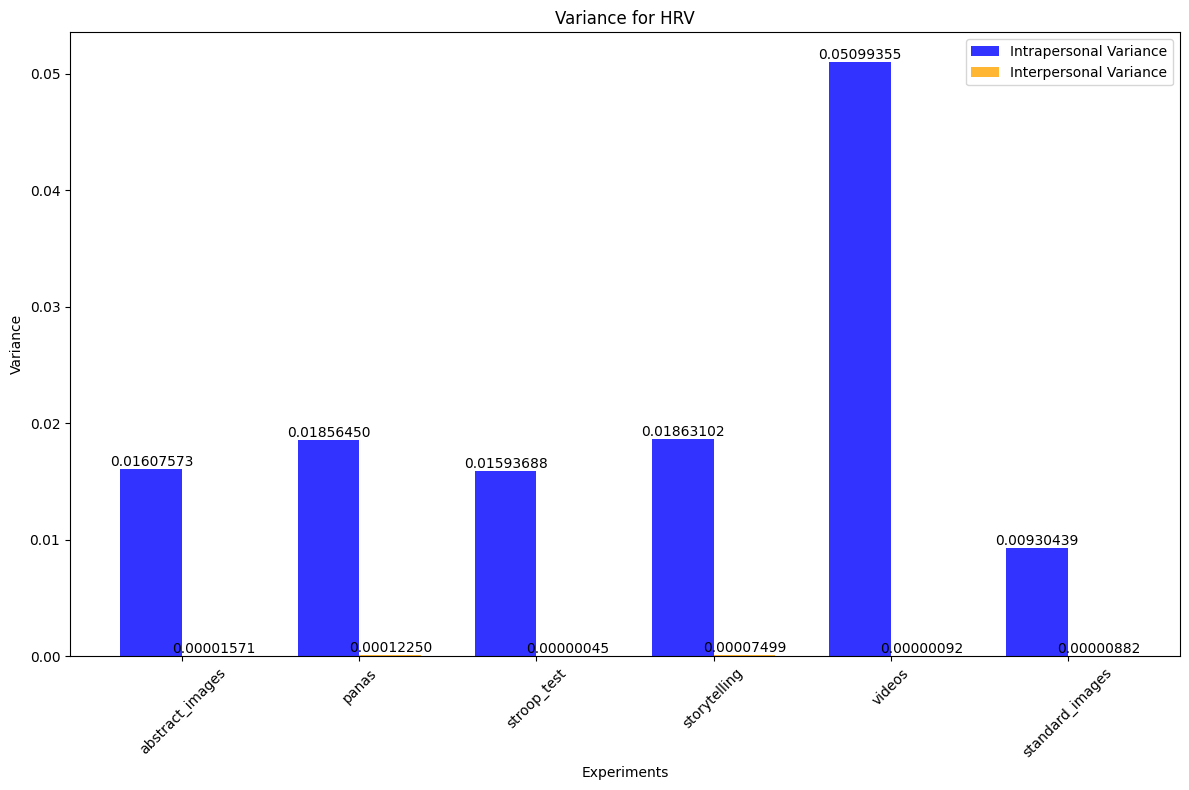

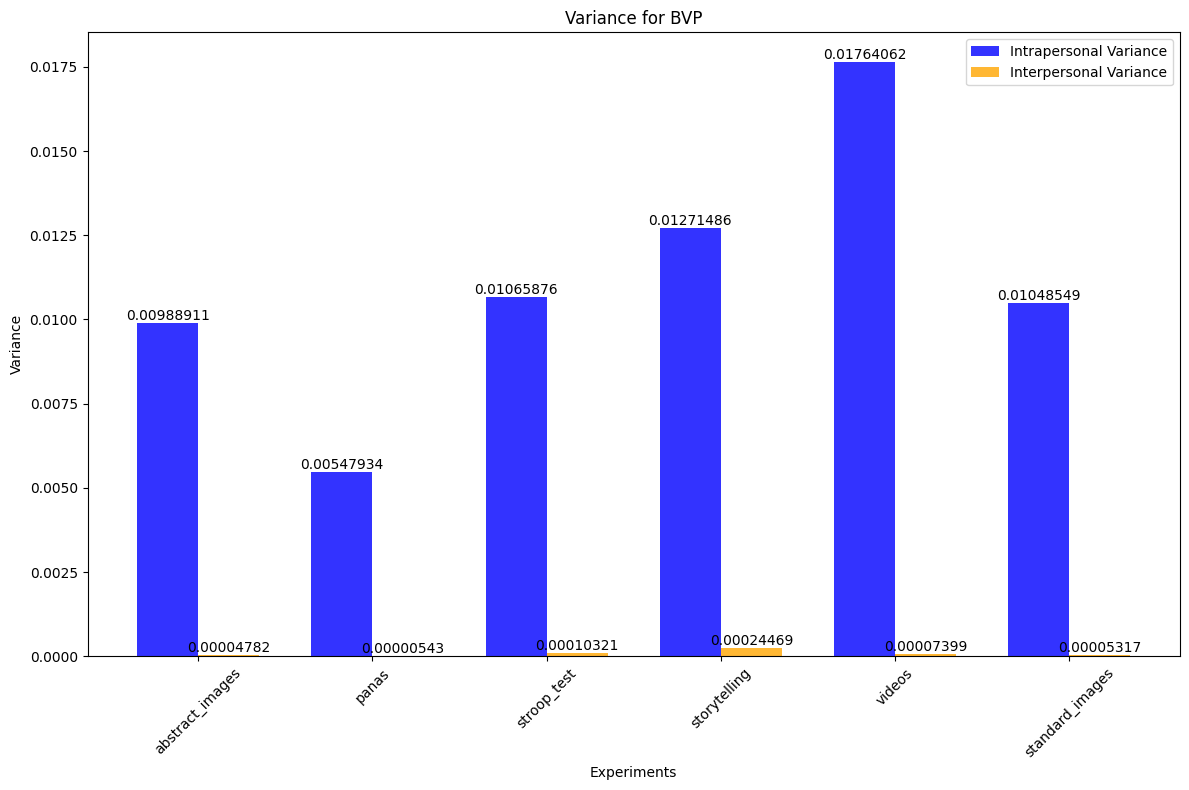

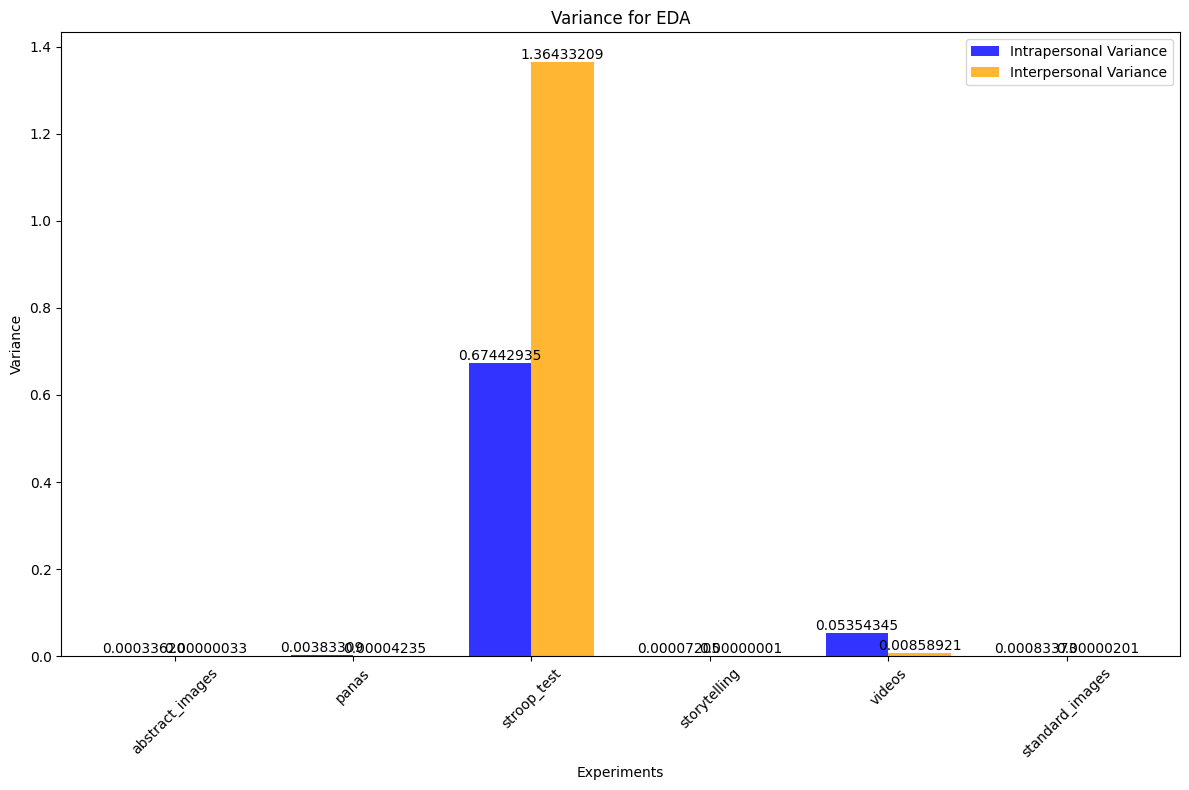

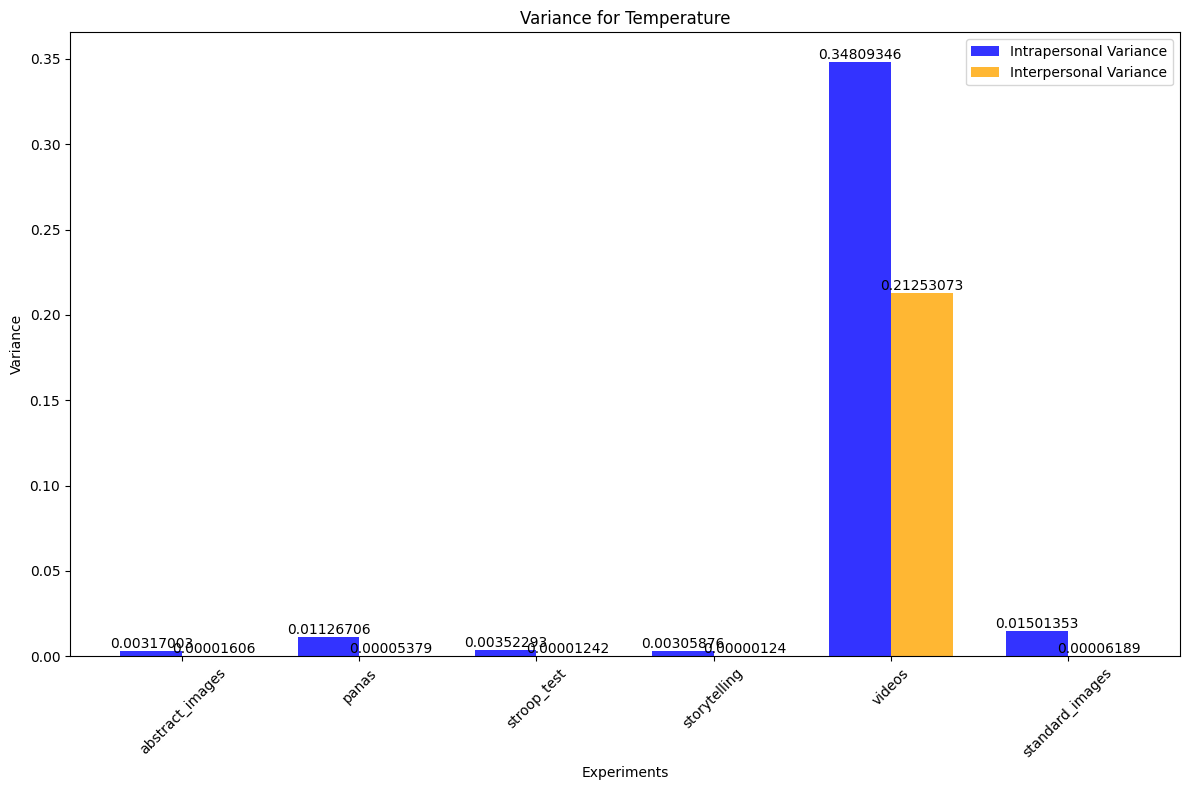

In [208]:
# Initialize a dictionary to hold the variances
all_experiment_variances = {}

# Process each experiment
for experiment, df in intrapersonal_variances_dict.items():
    # Calculate interpersonal variance for each metric
    interpersonal_variances = df.var(axis=0)
    
    # Calculate the mean of intrapersonal variances for each metric
    intrapersonal_mean = df.mean(axis=0)
    
    # Apply log normalization (add a small constant to avoid log(0))
    small_constant = 1e-10
    intrapersonal_log = intrapersonal_mean 
    interpersonal_log = interpersonal_variances 
    
    # Store in a DataFrame
    combined_variances = pd.DataFrame({
        'Intrapersonal Variance': intrapersonal_log,
        'Interpersonal Variance': interpersonal_log
    })
    
    all_experiment_variances[experiment] = combined_variances

# Create overlapping bar charts for each metric and each experiment
metrics = ['HRV', 'BVP', 'EDA', 'Temperature']
bar_width = 0.35  # Width of bars
opacity = 0.8    # Opacity for overlapping effect

for metric in metrics:
    plt.figure(figsize=(12, 8))
    
    # Collect data for the current metric
    intrapersonal_values = []
    interpersonal_values = []
    experiments = list(all_experiment_variances.keys())
    
    for experiment in experiments:
        df = all_experiment_variances[experiment]
        intrapersonal_values.append(df.loc[metric, 'Intrapersonal Variance'])
        interpersonal_values.append(df.loc[metric, 'Interpersonal Variance'])
    
    # Bar positions
    index = np.arange(len(experiments))  # The label locations
    bar_positions_intra = index - bar_width / 2  # Shift bars left
    bar_positions_inter = index + bar_width / 2  # Shift bars right
    
    # Create overlapping bar chart
    bars_intra = plt.bar(bar_positions_intra, intrapersonal_values, bar_width, alpha=opacity, color='blue', label='Intrapersonal Variance')
    bars_inter = plt.bar(bar_positions_inter, interpersonal_values, bar_width, alpha=opacity, color='orange', label='Interpersonal Variance')
    
    # Add value annotations
    for bars in [bars_intra, bars_inter]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2.0, height,
                     f'{height:.8f}',  # Format values to 2 decimal places
                     ha='center', va='bottom')
    
    plt.xlabel('Experiments')
    plt.ylabel('Variance')
    plt.title(f'Variance for {metric}')
    plt.xticks(index, experiments, rotation=45)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

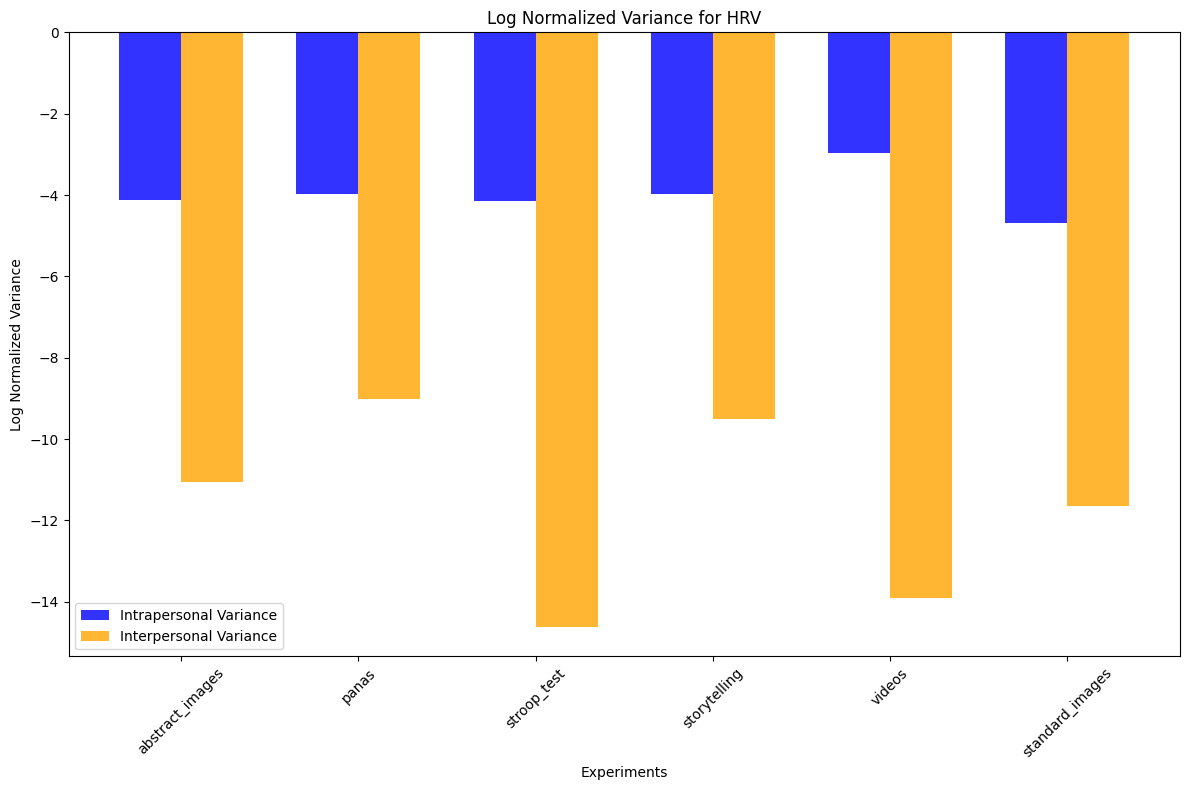

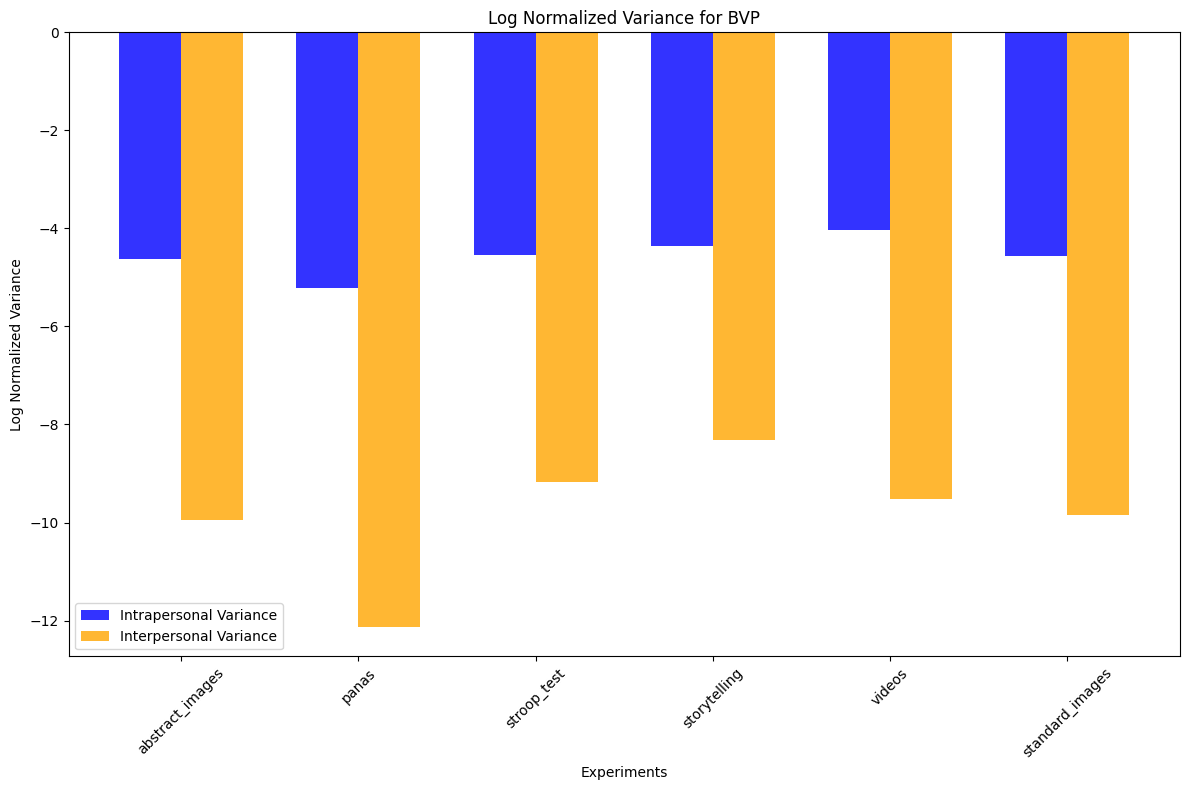

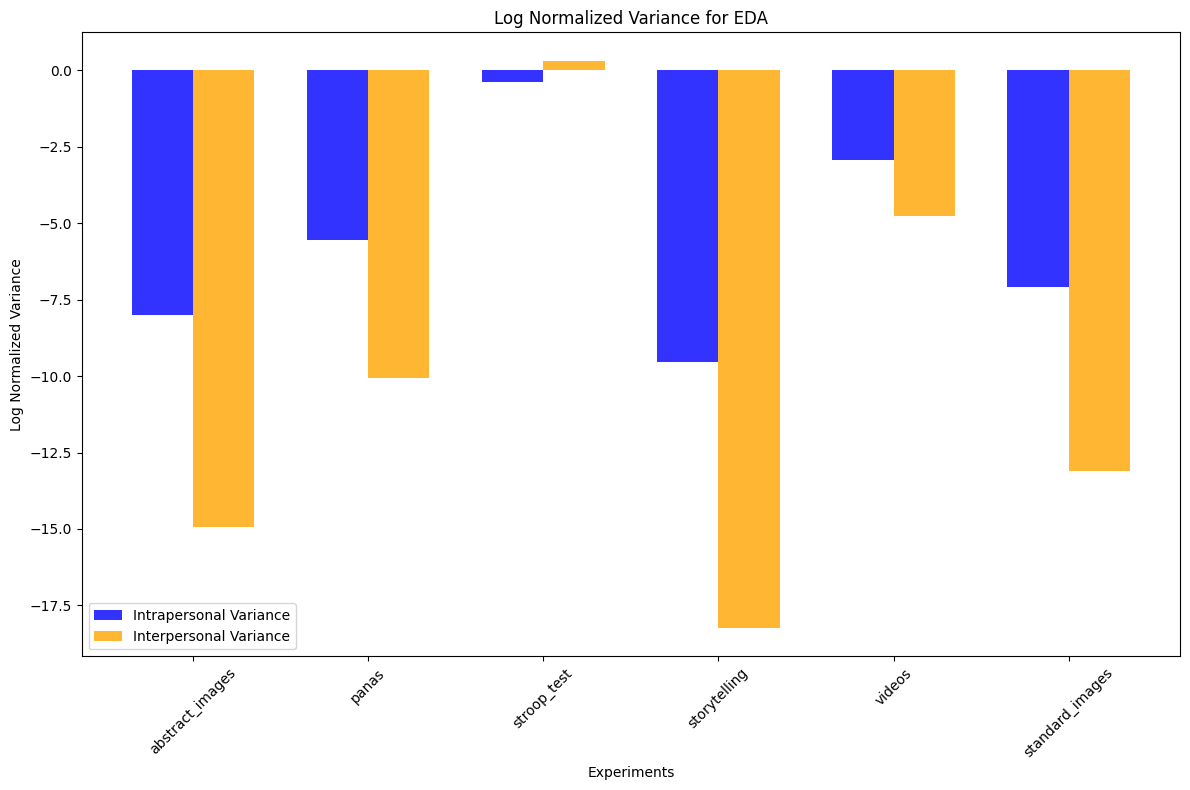

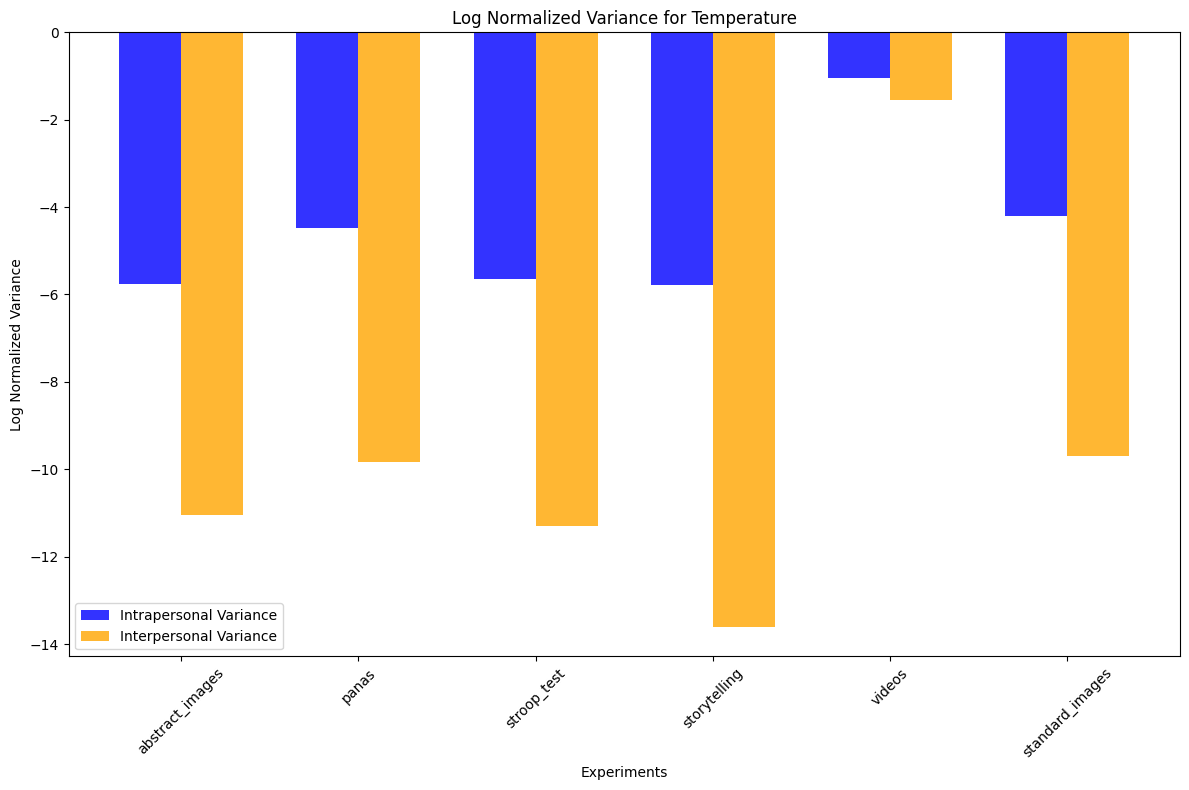

In [201]:
all_experiment_variances

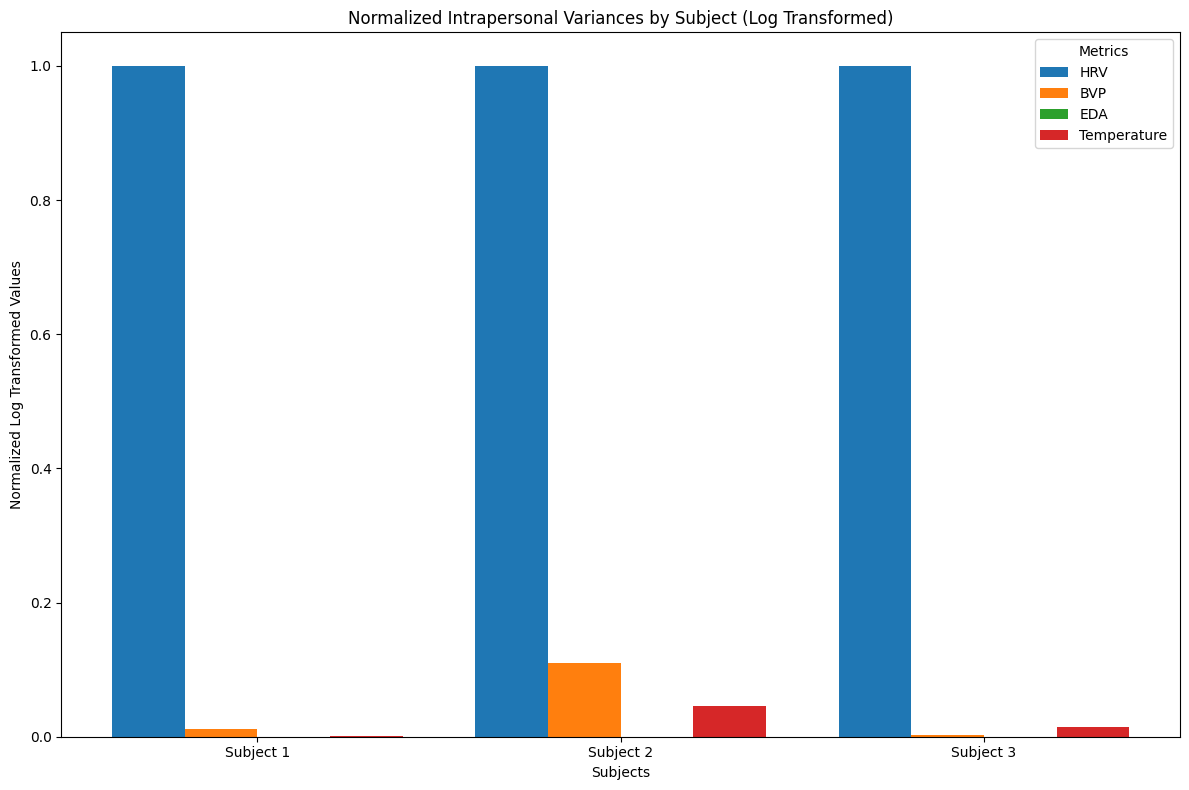

In [278]:
# Apply log transformation (adding a small constant to avoid log(0))
log_transformed_df = np.log1p(intrapersonal_variances)

# Normalize the log-transformed data
normalized_log_df = min_max_normalize(log_transformed_df)

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(normalized_log_df.columns))
for i, metric in enumerate(normalized_log_df.index):
    ax.bar(x + i * bar_width, normalized_log_df.loc[metric], bar_width, label=metric)
ax.set_xlabel('Subjects')
ax.set_ylabel('Normalized Log Transformed Values')
ax.set_title('Normalized Intrapersonal Variances by Subject (Log Transformed)')
ax.set_xticks(x + bar_width * (len(normalized_log_df.index) - 1) / 2)
ax.set_xticklabels(normalized_log_df.columns)
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()


In [176]:
# Calculate the mean values for each modality across subjects
mean_bvp = [df_bvp_1['values'].mean(), df_bvp_2['values'].mean(), df_bvp_3['values'].mean()]
mean_eda = [df_eda_1['values'].mean(), df_eda_2['values'].mean(), df_eda_3['values'].mean()]
mean_temp = [df_temperature_1['values'].mean(), df_temperature_2['values'].mean(), df_temperature_3['values'].mean()]
mean_hrv = [df_temperature_1['values'].mean(), df_temperature_2['values'].mean(), df_temperature_3['values'].mean()]
# Calculate interpersonal variance for each modality
inter_variance_bvp = np.var(mean_bvp)
inter_variance_eda = np.var(mean_eda)
inter_variance_temp = np.var(mean_temp)

# Combine interpersonal variances into a DataFrame for easier visualization
interpersonal_variances = pd.DataFrame({
    'BVP': [inter_variance_bvp],
    'EDA': [inter_variance_eda],
    'Temperature': [inter_variance_temp]
}, index=['Interpersonal Variance'])

interpersonal_variances

,BVP,EDA,Temperature
Interpersonal Variance,3.906697e-09,0.042072,0.248451


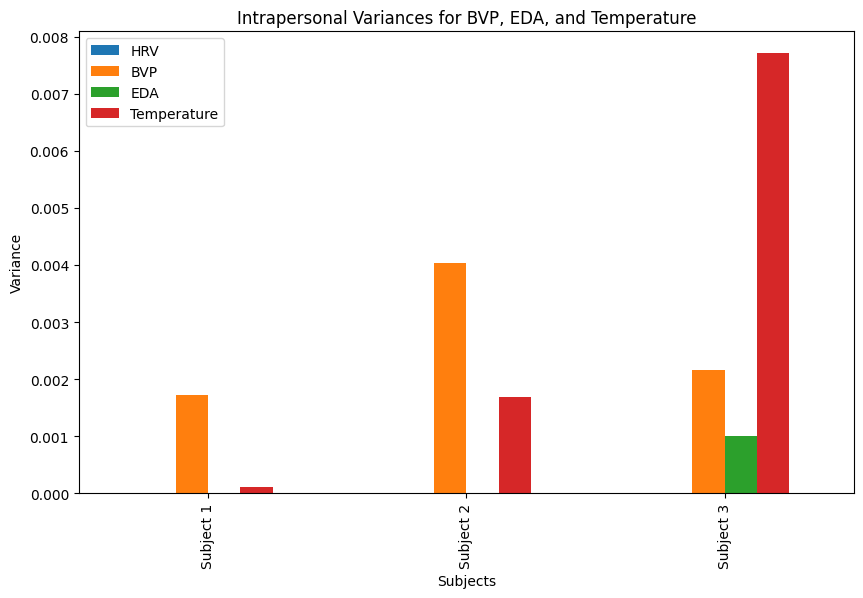

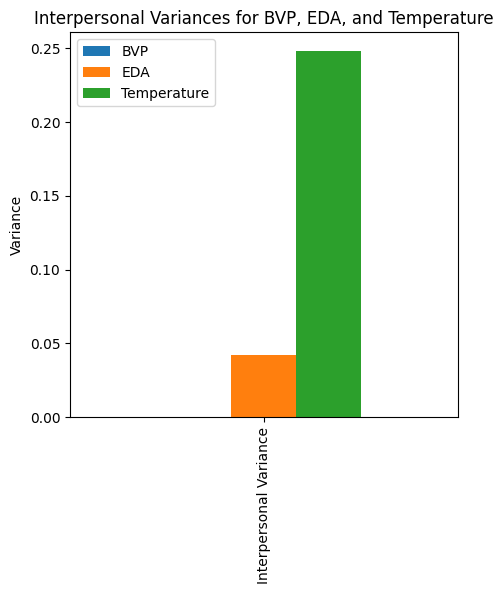

In [184]:
import matplotlib.pyplot as plt

# Plotting intrapersonal variances
intrapersonal_variances.T.plot(kind='bar', figsize=(10, 6))
plt.title('Intrapersonal Variances for BVP, EDA, and Temperature')
plt.ylabel('Variance')
plt.xlabel('Subjects')
plt.show()

# Plotting interpersonal variances
interpersonal_variances.plot(kind='bar', figsize=(5, 5))
plt.title('Interpersonal Variances for BVP, EDA, and Temperature')
plt.ylabel('Variance')
plt.show()
